# 05 — Mini Sampler Synth

**Level:** Advanced

Put the pieces together: a small `MiniSampler` that stores root samples, maps MIDI notes, applies ADSR + filter, and renders a sequenced phrase (melody + drums + FX).

## Setup

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from audio_utils import (
    SR, hear, normalize, seconds, midi_to_hz, semitone_ratio,
    linear_resample, apply_adsr, one_pole_lowpass, mix,
)

## Design a tiny sample library

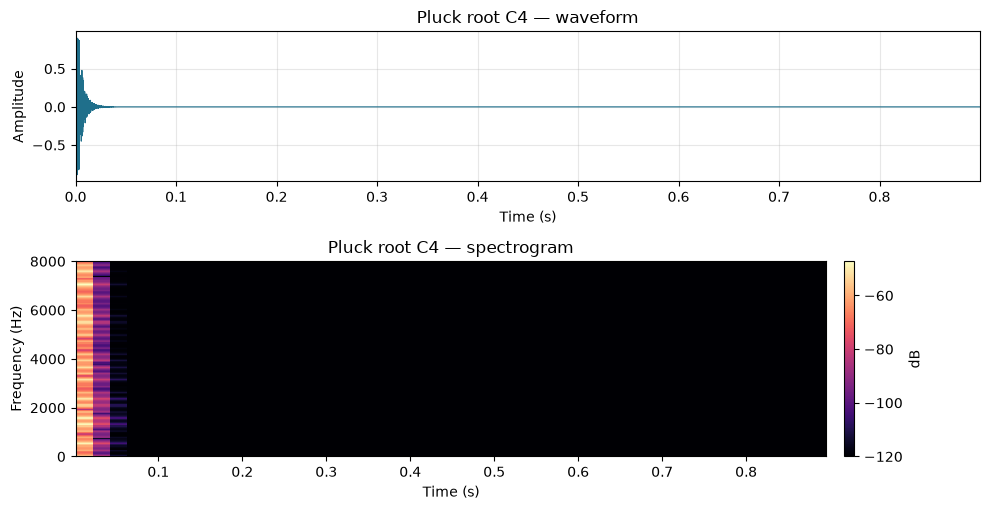

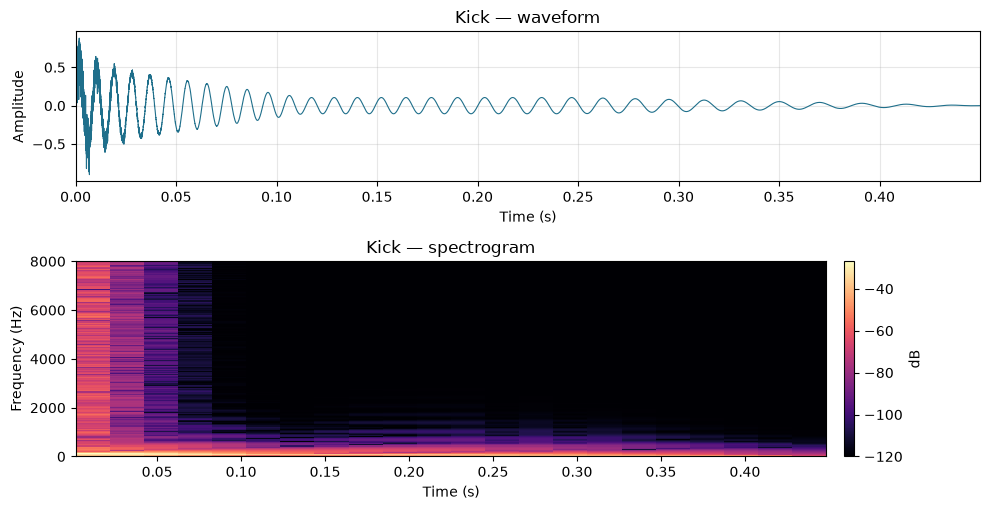

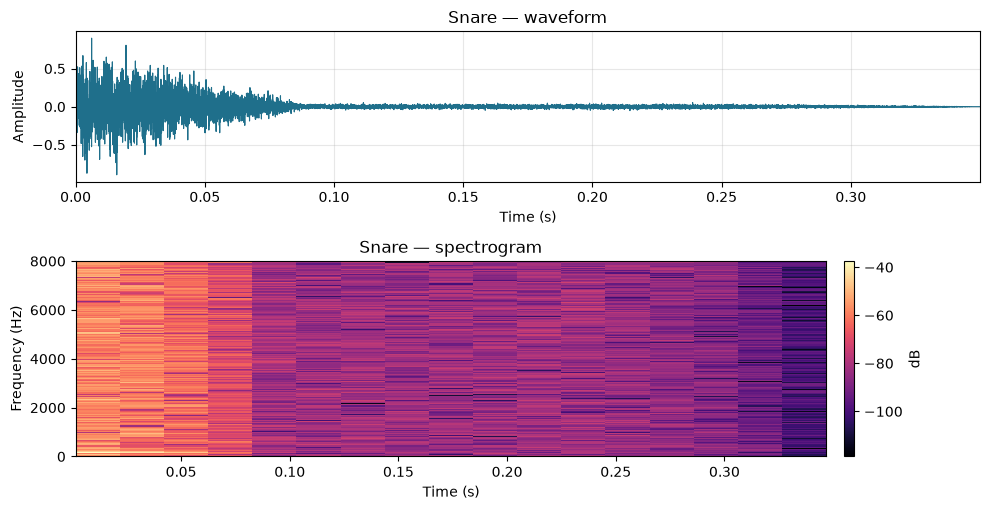

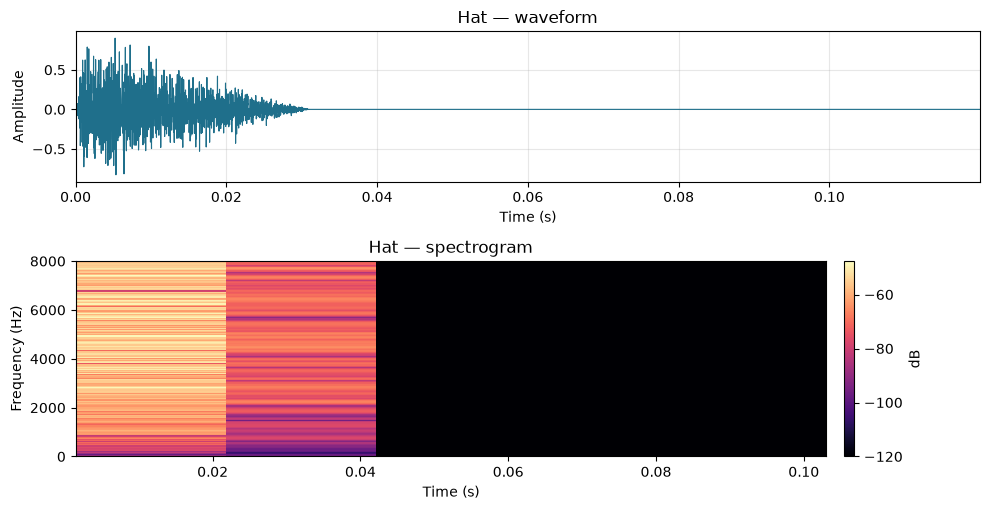

In [2]:
def synth_pluck(midi, dur=0.9, brightness=0.55):
    freq = midi_to_hz(midi)
    n = seconds(dur)
    delay = max(2, int(round(SR / freq)))
    rng = np.random.default_rng(100 + midi)
    buf = rng.uniform(-1, 1, delay)
    out = np.zeros(n)
    idx = 0
    for i in range(n):
        out[i] = buf[idx]
        buf[idx] = brightness * 0.5 * (buf[idx] + buf[(idx + 1) % delay])
        idx = (idx + 1) % delay
    return normalize(out)

def synth_kick(dur=0.45):
    t = np.arange(seconds(dur)) / SR
    # Pitch envelope: 120 Hz → 40 Hz
    freq = 120 * (40 / 120) ** (t / dur)
    phase = 2 * np.pi * np.cumsum(freq) / SR
    body = np.sin(phase)
    click = np.exp(-t * 80) * np.random.default_rng(0).normal(0, 1, len(t)) * 0.4
    return apply_adsr(normalize(body + click), attack=0.001, decay=0.2, sustain=0.2, release=0.2)

def synth_snare(dur=0.35):
    t = np.arange(seconds(dur)) / SR
    noise = np.random.default_rng(1).normal(0, 1, len(t))
    tone = np.sin(2 * np.pi * 180 * t) * np.exp(-t * 20)
    return apply_adsr(normalize(0.7 * noise + 0.5 * tone), attack=0.001, decay=0.15, sustain=0.05, release=0.1)

def synth_hat(dur=0.12):
    t = np.arange(seconds(dur)) / SR
    y = np.random.default_rng(2).normal(0, 1, len(t))
    y = one_pole_lowpass(y, 9000)  # still bright
    # crude high-pass via y - lowpass
    y = y - one_pole_lowpass(y, 5000)
    return apply_adsr(normalize(y), attack=0.001, decay=0.05, sustain=0.0, release=0.04)

# Preview library
for name, sig in [
    ("Pluck root C4", synth_pluck(60)),
    ("Kick", synth_kick()),
    ("Snare", synth_snare()),
    ("Hat", synth_hat()),
]:
    hear(sig, SR, title=name, show_spec=True)

## `MiniSampler` engine

Zones, velocity → gain/brightness, ADSR, optional cutoff. This is a teaching model of a ROMpler voice path.

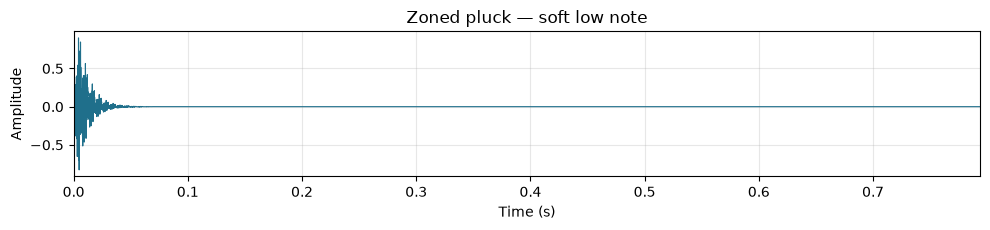

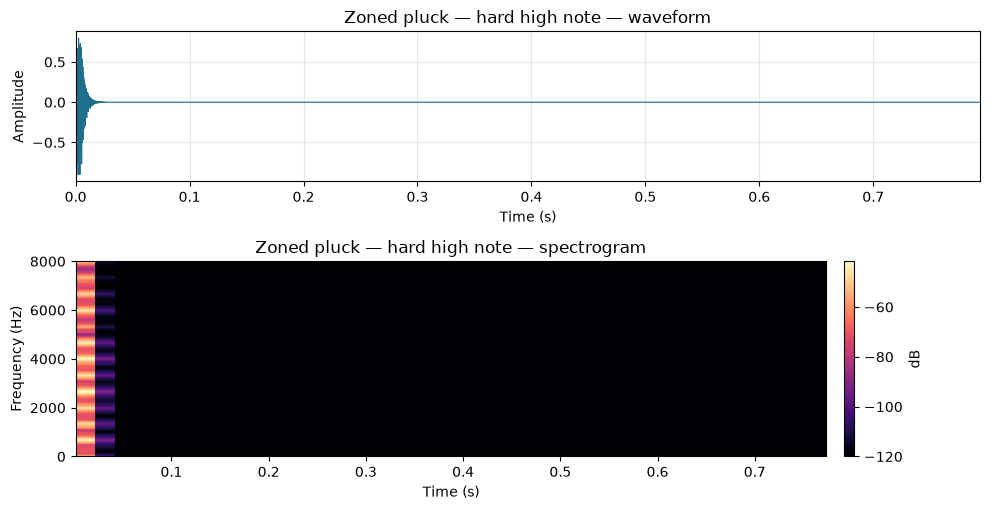

In [3]:
class MiniSampler:
    def __init__(self, roots: dict[str, tuple[np.ndarray, int]]):
        """roots: name → (buffer, root_midi)"""
        self.roots = roots

    def note(
        self,
        patch: str,
        midi: int,
        velocity: int = 100,
        attack=0.01,
        decay=0.12,
        sustain=0.5,
        release=0.2,
        cutoff_hz: float | None = None,
    ) -> np.ndarray:
        buf, root_midi = self.roots[patch]
        rate = semitone_ratio(midi - root_midi)
        x = linear_resample(buf, rate)
        # Velocity: gain + mild brightness via less filtering when hard
        vel = np.clip(velocity / 127, 0, 1)
        x = apply_adsr(x, attack=attack, decay=decay, sustain=sustain * vel, release=release)
        if cutoff_hz is not None:
            # Soft notes close the filter more
            fc = cutoff_hz * (0.4 + 0.6 * vel)
            x = one_pole_lowpass(x, fc)
        return normalize(x) * (0.35 + 0.65 * vel)

sampler = MiniSampler(
    {
        "pluck_low": (synth_pluck(48, dur=1.0), 48),
        "pluck_high": (synth_pluck(72, dur=1.0, brightness=0.65), 72),
        "kick": (synth_kick(), 60),
        "snare": (synth_snare(), 60),
        "hat": (synth_hat(), 60),
    }
)

# Zone helper for melodic patch
def melodic(midi, velocity=100):
    patch = "pluck_low" if midi < 60 else "pluck_high"
    return sampler.note(patch, midi, velocity=velocity, attack=0.005, decay=0.18, sustain=0.35, release=0.25, cutoff_hz=5000)

hear(melodic(52, 60), SR, title="Zoned pluck — soft low note")
hear(melodic(76, 120), SR, title="Zoned pluck — hard high note", show_spec=True)

## Sequencer — place notes on a timeline

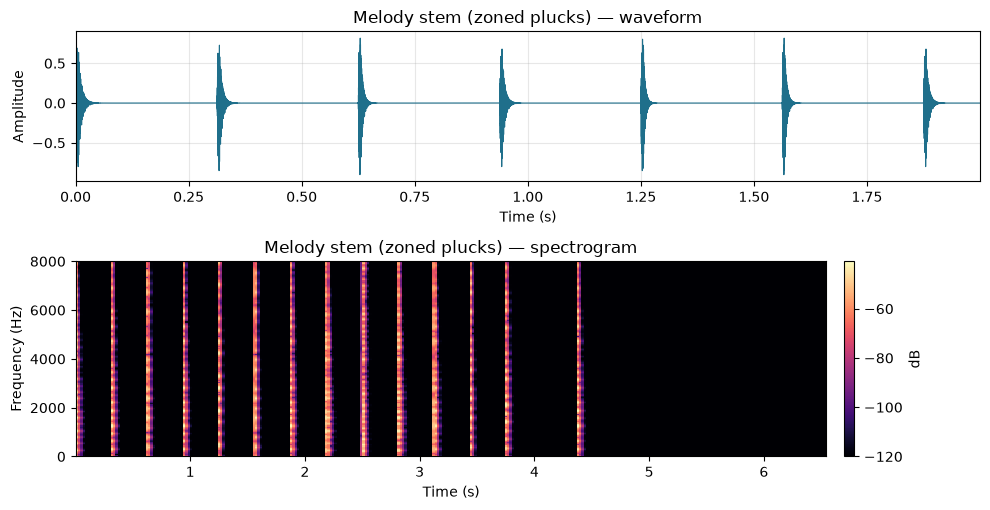

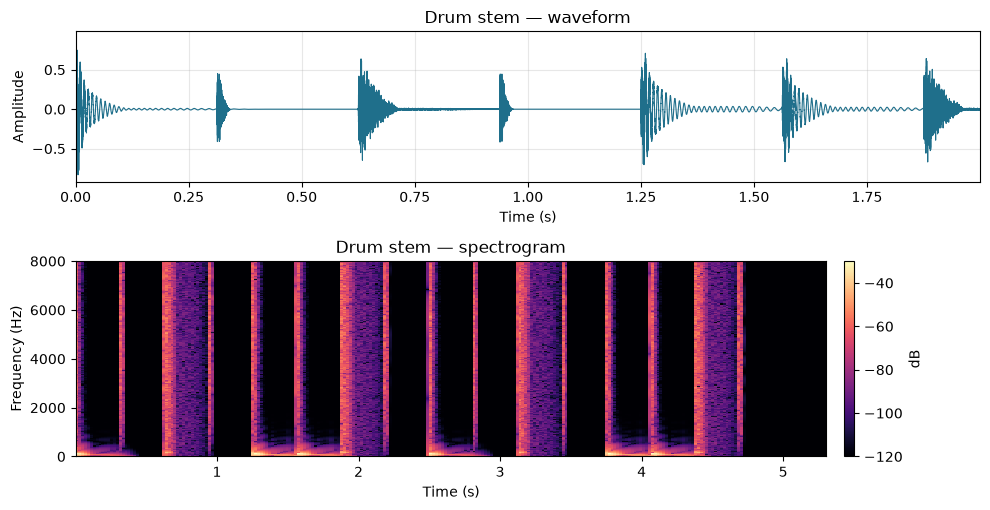

In [4]:
def place(events, bpm=96):
    """events: list of (beat, signal). Return mixed timeline."""
    beat_s = 60.0 / bpm
    rendered = []
    for beat, sig in events:
        start = int(round(beat * beat_s * SR))
        rendered.append((start, np.asarray(sig, dtype=np.float64).ravel()))
    n = max(start + len(sig) for start, sig in rendered) + seconds(0.5)
    out = np.zeros(n)
    for start, sig in rendered:
        out[start : start + len(sig)] += sig
    return normalize(out)

# 2-bar groove
melody_notes = [
    (0.0, 60), (0.5, 63), (1.0, 67), (1.5, 63),
    (2.0, 70), (2.5, 67), (3.0, 63), (3.5, 60),
    (4.0, 58), (4.5, 60), (5.0, 63), (5.5, 67),
    (6.0, 65), (7.0, 63),
]
mel_events = [(b, melodic(n, velocity=90 + (i % 3) * 10)) for i, (b, n) in enumerate(melody_notes)]

drum_events = []
for bar in (0, 4):
    for step in range(8):
        beat = bar + step * 0.5
        drum_events.append((beat, sampler.note("hat", 60, velocity=70, attack=0.001, decay=0.04, sustain=0.0, release=0.03)))
    drum_events.append((bar + 0.0, sampler.note("kick", 60, velocity=120, attack=0.001, decay=0.2, sustain=0.15, release=0.15)))
    drum_events.append((bar + 1.0, sampler.note("snare", 60, velocity=110)))
    drum_events.append((bar + 2.0, sampler.note("kick", 60, velocity=100)))
    drum_events.append((bar + 2.5, sampler.note("kick", 60, velocity=80)))
    drum_events.append((bar + 3.0, sampler.note("snare", 60, velocity=115)))

melody = place(mel_events, bpm=96)
drums = place(drum_events, bpm=96)
hear(melody, SR, title="Melody stem (zoned plucks)", show_spec=True)
hear(drums, SR, title="Drum stem", show_spec=True)

## Mix bus + FX

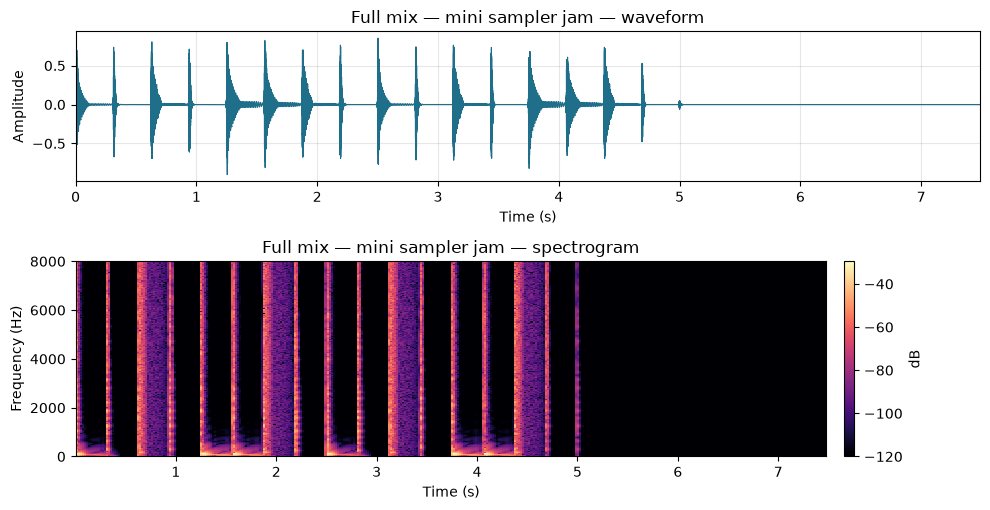

In [5]:
def delay_fx(x, delay_s=0.31, feedback=0.3, mix_amt=0.28):
    d = seconds(delay_s)
    y = np.zeros(len(x) + d * 3)
    y[: len(x)] = x
    for i in range(len(x)):
        y[i + d] += mix_amt * x[i]
        if i + 2 * d < len(y):
            y[i + 2 * d] += mix_amt * feedback * x[i]
    return y

melody_wet = delay_fx(one_pole_lowpass(melody, 4500))
# Match lengths and blend
bus = mix([melody_wet, drums], gains=[0.85, 0.9])
# Soft clip for glue
bus = np.tanh(1.2 * bus)
bus = normalize(bus, peak=0.95)

hear(bus, SR, title="Full mix — mini sampler jam", show_spec=True, max_waveform_seconds=None)

## Parameter exploration — same sequence, different tone

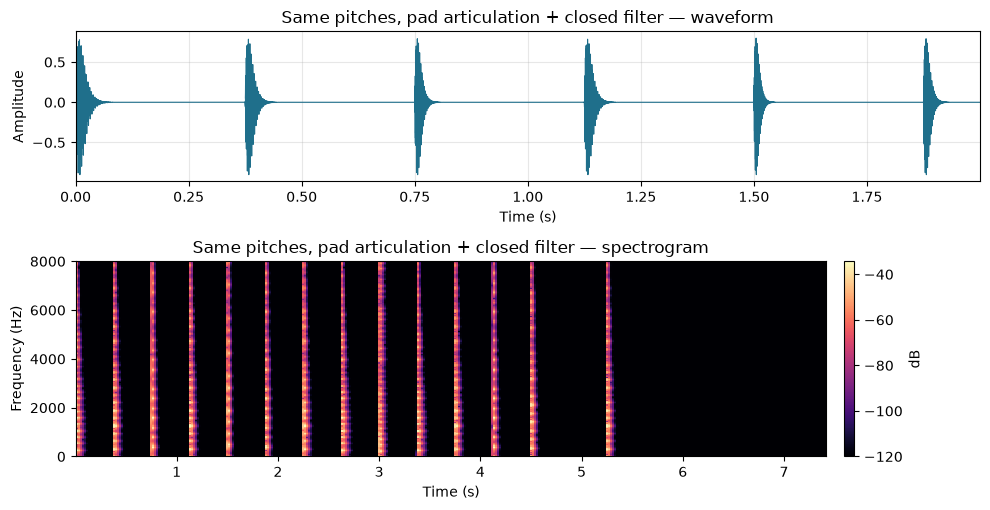

In [6]:
# Darker, slower pad-like articulation of the same pitches
pad_events = []
for b, n in melody_notes:
    patch = "pluck_low" if n < 60 else "pluck_high"
    pad_events.append(
        (
            b,
            sampler.note(
                patch, n, velocity=75,
                attack=0.2, decay=0.3, sustain=0.7, release=0.5,
                cutoff_hz=1800,
            ),
        )
    )
pad_take = place(pad_events, bpm=80)
hear(pad_take, SR, title="Same pitches, pad articulation + closed filter", show_spec=True)

## You should be able to…

- Describe a sampler voice path: zone → rate → ADSR → filter → FX
- Sequence melodic and percussive patches onto a beat grid
- Change articulation without changing the stored samples

### Where to go next

- Independent time-stretch / pitch-shift (phase vocoder, granular)
- Round-robin layers and release samples
- Convolution reverb and modulation FX racks
- Loading real WAV libraries into the same `MiniSampler` API